# Rossby number and the topographic PV gradient

## Aim

For shallow-water PV, `PV = (zeta + f) / h`. Neglecting horizontal gradients of relative vorticity gives

`grad(PV) = grad(f)/h - (zeta + f) grad(h)/h**2`.

With the **signed** Rossby number `Ro = zeta/f`, the topographic contribution is

`beta_topo = -f (1 + Ro) grad(h)/h**2`.

This notebook tests whether CE relative vorticity amplifies the same environmental slope while AE relative vorticity cancels it, and whether this helps explain the polarity-dependent tilt response. The existing `Ro` column is absolute-valued by `add_pv_gradient_terms`; this notebook deliberately recalculates `Ro_signed = w/f`. Here `w` is vertical relative vorticity, not vertical velocity.
## Direction convention after the gradient correction

All directions now refer to signed $\nabla PV$. The directional hypothesis is AE alignment and CE opposition. Raw mismatch is retained, while the main polarity-aware error is raw mismatch for AEs and $180^\circ-$raw mismatch for CEs. Magnitude and Rossby-number amplification results are unchanged; directional results must be recomputed.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

## 1. Load data and construct signed Rossby-number diagnostics

In [2]:
MAX_DEPTH_m = 3000.0
MIN_TILT_km = 5.0
ALIGNMENT_DEG = 45.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
df = tilt.add_pv_gradient_terms(df, grid, core_mean=True)

config = PVAlignmentConfig(
    dominance_factor=2.0, max_topo_depth_m=MAX_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df, config)
assert d.beta.dropna().median() > 0, 'Expected positive planetary beta after gradient sign correction.'

# add_pv_gradient_terms stores abs(w/f) as Ro; retain it but use the signed value here.
d['Ro_abs_existing'] = d.Ro
d['Ro_signed'] = d.w / d.f
d['absolute_vorticity_factor'] = 1.0 + d.Ro_signed
d['abs_vort_from_Ro'] = d.f * d.absolute_vorticity_factor
d['slope_mag'] = np.hypot(d.dhdx, d.dhdy)

# Counterfactual topographic PV gradient if relative vorticity were zero.
d['PV_grad_topo_fonly_x'] = -d.f * d.dhdx / d.h**2
d['PV_grad_topo_fonly_y'] = -d.f * d.dhdy / d.h**2
d['PV_grad_topo_fonly_mag'] = np.hypot(d.PV_grad_topo_fonly_x, d.PV_grad_topo_fonly_y)
d['vorticity_amplification'] = d.PV_grad_topo_mag / d.PV_grad_topo_fonly_mag
d['topo_plan_ratio_linear'] = d.PV_grad_topo_mag / d.PV_grad_plan_mag
d['topo_plan_ratio_fonly'] = d.PV_grad_topo_fonly_mag / d.PV_grad_plan_mag
d['raw_signed_PV_mismatch'] = d.dtheta_PV_grad
d['preference_error'] = np.where(d.Cyc.eq('AE'),d.raw_signed_PV_mismatch,180.0-d.raw_signed_PV_mismatch)
d['predicted_30'] = d.preference_error <= ALIGNMENT_DEG
d['response_cosine'] = np.cos(np.deg2rad(d.raw_signed_PV_mismatch))

valid = d.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    'Ro_signed', 'PV_grad_topo_mag', 'PV_grad_topo_fonly_mag',
    'PV_grad_plan_mag', 'dtheta_PV_grad', 'TiltDis',
])
valid = valid[(valid.h <= MAX_DEPTH_m) & valid.direction_valid].copy()

print(f'{len(valid):,} directional observations from {valid.Eddy.nunique():,} eddies')
display(valid.groupby('Cyc').agg(observations=('Eddy', 'size'), eddies=('Eddy', 'nunique')).astype(int))

14,483 directional observations from 903 eddies


,observations,eddies
Cyc,,
AE,5958,340
CE,8525,563


## 2. Algebra and sign checks

The computed amplification should equal `abs(1 + Ro_signed)`. CEs should normally have positive signed Ro; AEs should normally have negative signed Ro. Values with `1 + Ro_signed <= 0` imply zero or reversed absolute vorticity and require individual inspection.

In [3]:
check = np.abs(valid.vorticity_amplification - np.abs(valid.absolute_vorticity_factor))
print(f'Max amplification identity error: {check.max():.3e}')
print(f'Max abs-vorticity identity error: {(valid.abs_vort - valid.abs_vort_from_Ro).abs().max():.3e}')

sign_summary = valid.groupby('Cyc').agg(
    median_Ro=('Ro_signed', 'median'),
    q05_Ro=('Ro_signed', lambda x: x.quantile(.05)),
    q95_Ro=('Ro_signed', lambda x: x.quantile(.95)),
    median_factor=('absolute_vorticity_factor', 'median'),
    fraction_factor_nonpositive=('absolute_vorticity_factor', lambda x: (x <= 0).mean()),
)
display(sign_summary.round(3))
display(valid.loc[valid.absolute_vorticity_factor <= 0,
                  ['Eddy', 'Day', 'Cyc', 'lat', 'f', 'w', 'Ro_signed', 'absolute_vorticity_factor']]
        .sort_values('Ro_signed').head(30))

Max amplification identity error: 8.882e-16
Max abs-vorticity identity error: 2.711e-20


,median_Ro,q05_Ro,q95_Ro,median_factor,fraction_factor_nonpositive
Cyc,,,,,
AE,-0.227,-0.528,-0.102,0.773,0.0
CE,0.279,0.117,0.888,1.279,0.0


,Eddy,Day,Cyc,lat,f,w,Ro_signed,absolute_vorticity_factor
49302,1137,4999,AE,-36.747751,-0.000087,0.000096,-1.095245,-0.095245


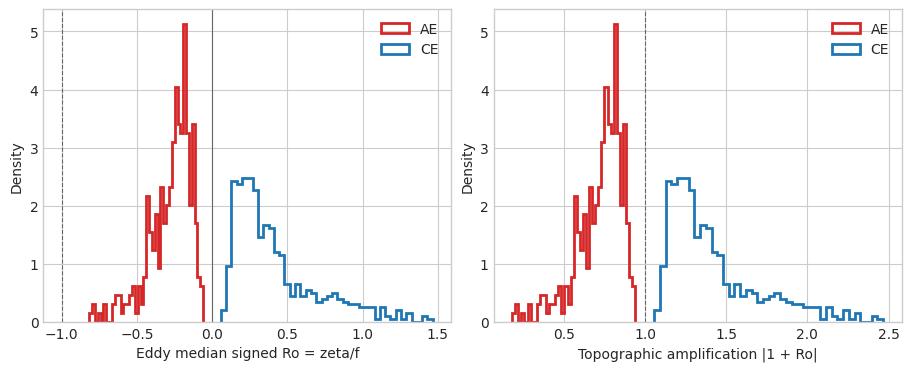

In [4]:
eddy_ro = (valid.groupby(['Cyc', 'Eddy'], as_index=False)
           .agg(Ro_signed=('Ro_signed', 'median'),
                factor=('absolute_vorticity_factor', 'median'),
                amplification=('vorticity_amplification', 'median'),
                latitude=('lat', 'median'), observations=('Day', 'size')))

fig, axs = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    part = eddy_ro[eddy_ro.Cyc == cyc]
    axs[0].hist(part.Ro_signed, bins=40, density=True, histtype='step', lw=2, color=color, label=cyc)
    axs[1].hist(part.amplification, bins=40, density=True, histtype='step', lw=2, color=color, label=cyc)
axs[0].axvline(0, color='0.4', lw=.8)
axs[0].axvline(-1, color='0.4', ls='--', lw=.8)
axs[0].set(xlabel='Eddy median signed Ro = zeta/f', ylabel='Density')
axs[1].axvline(1, color='0.4', ls='--', lw=.8)
axs[1].set(xlabel='Topographic amplification |1 + Ro|', ylabel='Density')
for ax in axs: ax.legend(frameon=False)

## 3. How much of the CE-AE PV-gradient contrast comes from relative vorticity?

Compare the observed topographic term with the counterfactual obtained from the same latitude, depth and slope but with `zeta = 0`. Medians are first calculated within each eddy so long tracks do not dominate.

In [5]:
eddy_terms = (valid.groupby(['Cyc', 'Eddy'], as_index=False)
              .agg(full_topo=('PV_grad_topo_mag', 'median'),
                   fonly_topo=('PV_grad_topo_fonly_mag', 'median'),
                   plan=('PV_grad_plan_mag', 'median'),
                   slope=('slope_mag', 'median'), depth=('h', 'median'),
                   latitude=('lat', 'median'), Ro_signed=('Ro_signed', 'median')))
summary = eddy_terms.groupby('Cyc').agg(
    eddies=('Eddy', 'size'),
    median_full_topo=('full_topo', 'median'),
    median_fonly_topo=('fonly_topo', 'median'),
    median_plan=('plan', 'median'),
)
display(summary)
for term in ['full_topo', 'fonly_topo']:
    ratio = summary.loc['CE', f'median_{term}'] / summary.loc['AE', f'median_{term}']
    print(f'CE/AE ratio for {term}: {ratio:.2f}')

,eddies,median_full_topo,median_fonly_topo,median_plan
Cyc,,,,
AE,340,1.379589e-13,1.817688e-13,7.820388e-15
CE,563,4.646758e-13,3.424637e-13,8.108070e-15


CE/AE ratio for full_topo: 3.37
CE/AE ratio for fonly_topo: 1.88


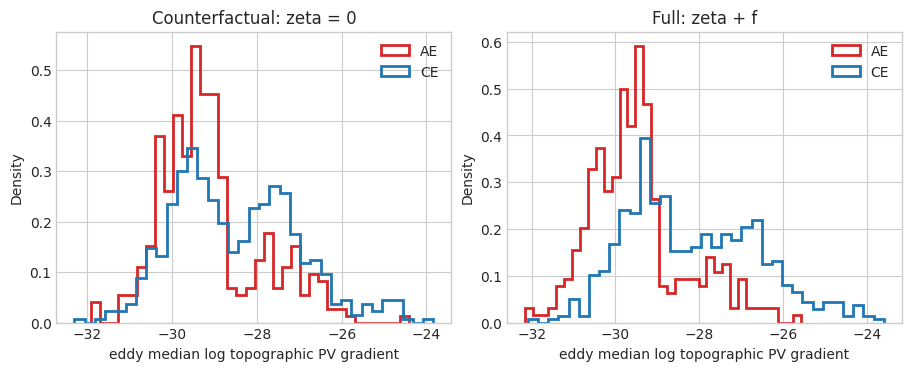

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    part = eddy_terms[eddy_terms.Cyc == cyc]
    axs[0].hist(np.log(part.fonly_topo), bins=35, density=True, histtype='step', lw=2, color=color, label=cyc)
    axs[1].hist(np.log(part.full_topo), bins=35, density=True, histtype='step', lw=2, color=color, label=cyc)
axs[0].set(title='Counterfactual: zeta = 0', xlabel='eddy median log topographic PV gradient', ylabel='Density')
axs[1].set(title='Full: zeta + f', xlabel='eddy median log topographic PV gradient', ylabel='Density')
for ax in axs: ax.legend(frameon=False)

## 4. Latitude dependence

Rossby number changes with latitude because `f` changes. However, the dimensional topographic coefficient is `f(1 + Ro) = f + zeta`; Ro should therefore be interpreted together with `f`, not alone.

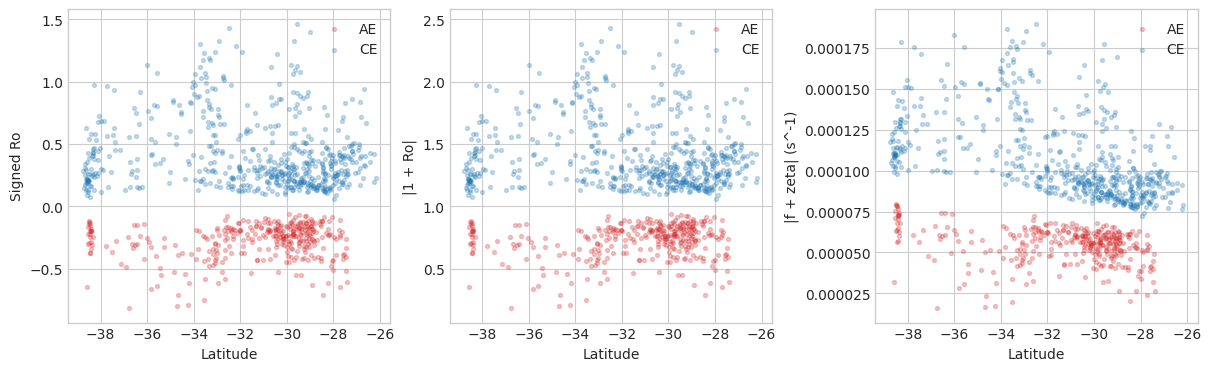

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    part = eddy_terms[eddy_terms.Cyc == cyc]
    axs[0].scatter(part.latitude, part.Ro_signed, s=8, alpha=.25, color=color, label=cyc)
    axs[1].scatter(part.latitude, np.abs(part.Ro_signed + 1), s=8, alpha=.25, color=color, label=cyc)
    # Recover median dimensional absolute vorticity for the same eddies.
    av = valid[valid.Cyc == cyc].groupby('Eddy').abs_vort.median().reindex(part.Eddy)
    axs[2].scatter(part.latitude, np.abs(av), s=8, alpha=.25, color=color, label=cyc)
axs[0].set(xlabel='Latitude', ylabel='Signed Ro')
axs[1].set(xlabel='Latitude', ylabel='|1 + Ro|')
axs[2].set(xlabel='Latitude', ylabel='|f + zeta| (s^-1)')
for ax in axs: ax.legend(frameon=False)

## 5. Alignment across the full topographic-to-planetary transition

Do not preselect only topographic-dominated observations when looking for the transition. The key nondimensional predictor is `|beta_topo| / |beta_plan| = |f(1 + Ro)| |grad(h)| / (beta h)`. Random unsigned orientation gives a median mismatch of 90 degrees and `P(mismatch <= 30 degrees) = 16.7%`.

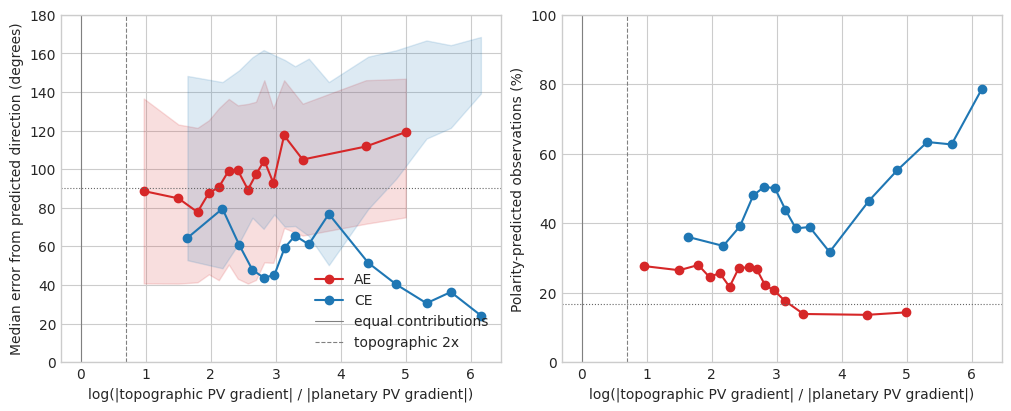

In [8]:
transition = d.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    'topo_plan_ratio', 'dtheta_PV_grad', 'Ro_signed', 'TiltDis',
]).copy()
transition = transition[(transition.h <= MAX_DEPTH_m) & transition.direction_valid]
transition['raw_signed_PV_mismatch'] = transition.dtheta_PV_grad
transition['preference_error'] = np.where(transition.Cyc.eq('AE'),transition.raw_signed_PV_mismatch,180.0-transition.raw_signed_PV_mismatch)
transition['predicted_30'] = transition.preference_error <= ALIGNMENT_DEG

def binned_response(part, x='topo_plan_ratio', n_bins=15):
    part = part.copy()
    part['bin'] = pd.qcut(part[x], n_bins, duplicates='drop')
    return (part.groupby('bin', observed=True)
            .agg(x=(x, 'median'), angle=('preference_error','median'),
                 q25=('dtheta_PV_grad', lambda z: z.quantile(.25)),
                 q75=('dtheta_PV_grad', lambda z: z.quantile(.75)),
                 p_aligned=('predicted_30','mean'), observations=('Eddy', 'size'),
                 eddies=('Eddy', 'nunique')).reset_index(drop=True))

fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    stats = binned_response(transition[transition.Cyc == cyc])
    axs[0].plot(stats.x, stats.angle, '-o', color=color, label=cyc)
    axs[0].fill_between(stats.x, stats.q25, stats.q75, color=color, alpha=.15)
    axs[1].plot(stats.x, 100 * stats.p_aligned, '-o', color=color, label=cyc)
axs[0].axhline(90, color='0.4', ls=':', lw=.8)
axs[1].axhline(100/6, color='0.4', ls=':', lw=.8)
for ax in axs:
    ax.axvline(0, color='0.5', lw=.8, label='equal contributions')
    ax.axvline(np.log(2), color='0.5', ls='--', lw=.8, label='topographic 2x')
    ax.set_xlabel('log(|topographic PV gradient| / |planetary PV gradient|)')
axs[0].set(ylabel='Median error from predicted direction (degrees)', ylim=(0, 180))
axs[1].set(ylabel='Polarity-predicted observations (%)', ylim=(0, 100))
axs[0].legend(frameon=False)

## 6. Separate environmental slope from vorticity amplification

The full topographic term is the product of an environmental term and an eddy term: `B0 = |f| |grad(h)| / h**2` and `A = |1 + Ro|`. Plotting alignment against both prevents a stronger CE response from being attributed solely to either steeper sampled slopes or stronger relative vorticity.

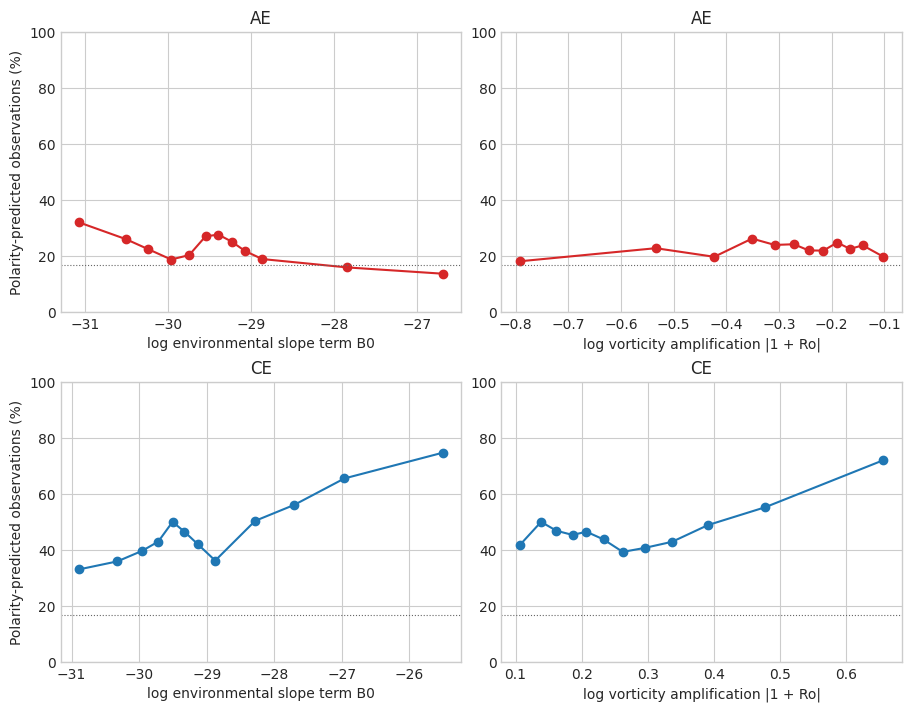

In [9]:
valid['log_B0'] = np.log(valid.PV_grad_topo_fonly_mag)
valid['log_A'] = np.log(valid.vorticity_amplification)

fig, axs = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
for i, (cyc, color) in enumerate([('AE', 'tab:red'), ('CE', 'tab:blue')]):
    part = valid[(valid.Cyc == cyc) & np.isfinite(valid.log_A)]
    for j, (x, label) in enumerate([('log_B0', 'log environmental slope term B0'),
                                     ('log_A', 'log vorticity amplification |1 + Ro|')]):
        stats = binned_response(part, x=x, n_bins=12)
        axs[i, j].plot(stats.x, 100 * stats.p_aligned, '-o', color=color)
        axs[i, j].axhline(100/6, color='0.4', ls=':', lw=.8)
        axs[i, j].set(title=cyc, xlabel=label, ylim=(0, 100))
        if j == 0: axs[i, j].set_ylabel('Polarity-predicted observations (%)')

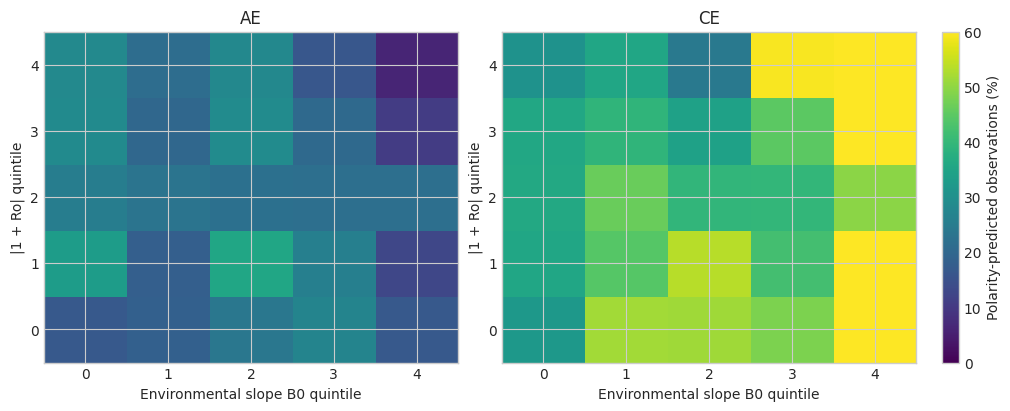

In [10]:
# Two-dimensional descriptive heatmaps. Blank cells contain too few unique eddies.
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, cyc in zip(axs, ['AE', 'CE']):
    part = valid[(valid.Cyc == cyc) & np.isfinite(valid.log_A)].copy()
    part['B_bin'] = pd.qcut(part.log_B0, 5, labels=False, duplicates='drop')
    part['A_bin'] = pd.qcut(part.log_A, 5, labels=False, duplicates='drop')
    grouped = part.groupby(['A_bin', 'B_bin'], observed=True)
    probability = grouped.predicted_30.mean().unstack() * 100
    n_eddies = grouped.Eddy.nunique().unstack()
    probability = probability.where(n_eddies >= 10)
    image = ax.imshow(probability, origin='lower', aspect='auto', vmin=0, vmax=60, cmap='viridis')
    ax.set(title=cyc, xlabel='Environmental slope B0 quintile', ylabel='|1 + Ro| quintile')
fig.colorbar(image, ax=axs, label='Polarity-predicted observations (%)', fraction=.03, pad=.03)

## 7. Environmental matching

Bin eddies by latitude, depth and slope using common edges, then compare CE and AE topographic terms only inside environmental strata containing both polarities. This is a transparent first check before a formal matched or mixed-effects analysis.

In [11]:
matched = eddy_terms.copy()
matched['lat_bin'] = pd.cut(matched.latitude, bins=np.linspace(matched.latitude.min(), matched.latitude.max(), 7), include_lowest=True)
matched['depth_bin'] = pd.cut(matched.depth, bins=np.linspace(matched.depth.min(), matched.depth.max(), 7), include_lowest=True)
matched['slope_bin'] = pd.qcut(matched.slope, 6, duplicates='drop')
strata = (matched.groupby(['lat_bin', 'depth_bin', 'slope_bin', 'Cyc'], observed=True)
          .agg(n=('Eddy', 'size'), full=('full_topo', 'median'), fonly=('fonly_topo', 'median'),
               Ro=('Ro_signed', 'median')).reset_index())
paired = strata.pivot(index=['lat_bin', 'depth_bin', 'slope_bin'], columns='Cyc')
paired.columns = [f'{metric}_{cyc}' for metric, cyc in paired.columns]
paired = paired.dropna(subset=['full_AE', 'full_CE'])
paired = paired[(paired.n_AE >= 5) & (paired.n_CE >= 5)]
paired['CE_AE_full_ratio'] = paired.full_CE / paired.full_AE
paired['CE_AE_fonly_ratio'] = paired.fonly_CE / paired.fonly_AE
display(paired[['n_AE', 'n_CE', 'CE_AE_full_ratio', 'CE_AE_fonly_ratio']])
print(f'Matched strata: {len(paired)}')
print(f'Median matched CE/AE full ratio: {paired.CE_AE_full_ratio.median():.2f}')
print(f'Median matched CE/AE f-only ratio: {paired.CE_AE_fonly_ratio.median():.2f}')

n_AE  \
lat_bin            depth_bin            slope_bin                                 
(-38.774, -36.674] (1106.17, 1579.532]  (0.0421, 0.0666]                    7.0   
(-36.674, -34.575] (2052.895, 2526.257] (0.0666, 0.116]                     7.0   
                   (2526.257, 2999.62]  (0.0666, 0.116]                     7.0   
(-34.575, -32.476] (2526.257, 2999.62]  (0.0181, 0.0421]                   14.0   
(-32.476, -30.376] (1106.17, 1579.532]  (0.00015999999999999999, 0.00678]  13.0   
                   (1579.532, 2052.895] (0.00678, 0.0108]                  10.0   
                                        (0.0108, 0.0181]                    8.0   
                   (2526.257, 2999.62]  (0.0108, 0.0181]                    7.0   
                                        (0.0181, 0.0421]                   10.0   
(-30.376, -28.277] (1106.17, 1579.532]  (0.00015999999999999999, 0.00678]   9.0   
                   (1579.532, 2052.895] (0.00015999999999999999, 0.00678]   8.0   
                                        (0.00678, 0.0108]                   8.0   
                   (2052.895, 2526.257] (0.00678, 0.0108]                  14.0   
                                        (0.0108, 0.0181]                   13.0   
                   (2526.257, 2999.62]  (0.00015999999999999999, 0.00678]  18.0   
                                        (0.00678, 0.0108]                  27.0   
                                        (0.0108, 0.0181]                   19.0   
                                        (0.0181, 0.0421]                   10.0   
(-28.277, -26.178] (2526.257, 2999.62]  (0.00015999999999999999, 0.00678]   7.0   
                                        (0.00678, 0.0108]                   8.0   
                                        (0.0108, 0.0181]                    5.0   

                                                                           n_CE  \
lat_bin            depth_bin            slope_bin                                 
(-38.774, -36.674] (1106.17, 1579.532]  (0.0421, 0.0666]                    9.0   
(-36.674, -34.575] (2052.895, 2526.257] (0.0666, 0.116]                    11.0   
                   (2526.257, 2999.62]  (0.0666, 0.116]                     9.0   
(-34.575, -32.476] (2526.257, 2999.62]  (0.0181, 0.0421]                   11.0   
(-32.476, -30.376] (1106.17, 1579.532]  (0.00015999999999999999, 0.00678]  17.0   
                   (1579.532, 2052.895] (0.00678, 0.0108]                  10.0   
                                        (0.0108, 0.0181]                    8.0   
                   (2526.257, 2999.62]  (0.0108, 0.0181]                    8.0   
                                        (0.0181, 0.0421]                   13.0   
(-30.376, -28.277] (1106.17, 1579.532]  (0.00015999999999999999, 0.00678]   9.0   
                   (1579.532, 2052.895] (0.00015999999999999999, 0.00678]  11.0   
                                        (0.00678, 0.0108]                   8.0   
                   (2052.895, 2526.257] (0.00678, 0.0108]                  16.0   
                                        (0.0108, 0.0181]                   20.0   
                   (2526.257, 2999.62]  (0.00015999999999999999, 0.00678]  17.0   
                                        (0.00678, 0.0108]                  16.0   
                                        (0.0108, 0.0181]                   19.0   
                                        (0.0181, 0.0421]                   12.0   
(-28.277, -26.178] (2526.257, 2999.62]  (0.00015999999999999999, 0.00678]  17.0   
                                        (0.00678, 0.0108]                  15.0   
                                        (0.0108, 0.0181]                   12.0   

                                                                           CE_AE_full_ratio  \
lat_bin            depth_bin            slope_bin                                             
(-38.774, -36.674] (1106.17, 1579.532]  (0.0421, 0.0666]         

Matched strata: 21
Median matched CE/AE full ratio: 1.66
Median matched CE/AE f-only ratio: 1.02


## 8. Decisive geometric test: planetary, topographic and total-gradient directions

Increasing `1 + Ro` changes the magnitude of the topographic vector and can rotate the **total** PV-gradient direction even if the physical tilt does not change. Positive multiplication of the topographic term does not rotate its direction. The plots convert each raw angle into polarity-aware error: decreasing error means stronger AE alignment or CE opposition.

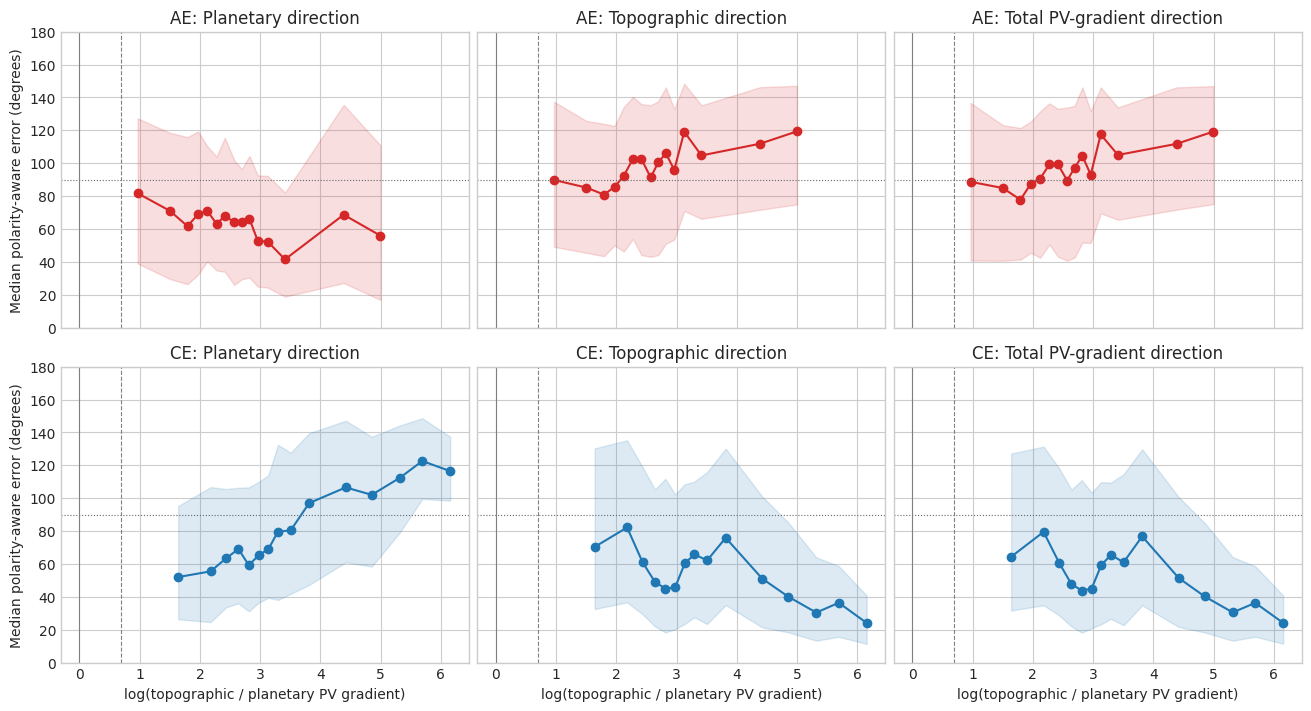

In [12]:
direction_columns = {
    'Planetary direction': 'dtheta_PV_grad_plan',
    'Topographic direction': 'dtheta_PV_grad_topo',
    'Total PV-gradient direction': 'dtheta_PV_grad',
}
fig, axs = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True, constrained_layout=True)
for i, (cyc, color) in enumerate([('AE', 'tab:red'), ('CE', 'tab:blue')]):
    part = transition[transition.Cyc == cyc].copy()
    part['ratio_bin'] = pd.qcut(part.topo_plan_ratio, 15, duplicates='drop')
    for j, (title, column) in enumerate(direction_columns.items()):
        part['direction_error'] = np.where(part.Cyc.eq('AE'), part[column], 180.0 - part[column])
        stats = (part.groupby('ratio_bin', observed=True)
                 .agg(x=('topo_plan_ratio', 'median'), angle=('direction_error', 'median'),
                      q25=('direction_error', lambda z: z.quantile(.25)),
                      q75=('direction_error', lambda z: z.quantile(.75)),
                      eddies=('Eddy', 'nunique')).reset_index(drop=True))
        ax = axs[i, j]
        ax.plot(stats.x, stats.angle, '-o', color=color)
        ax.fill_between(stats.x, stats.q25, stats.q75, color=color, alpha=.15)
        ax.axhline(90, color='0.4', ls=':', lw=.8)
        ax.axvline(0, color='0.5', lw=.8)
        ax.axvline(np.log(2), color='0.5', ls='--', lw=.8)
        ax.set(title=f'{cyc}: {title}', ylim=(0, 180))
        if i == 1: ax.set_xlabel('log(topographic / planetary PV gradient)')
        if j == 0: ax.set_ylabel('Median polarity-aware error (degrees)')

## 9. Departure from the planetary-dominated natural tilt

Estimate one background tilt bearing for each polarity from deep (`h >= 3000 m`), planetary-dominated observations. The proposed override mechanism predicts increasing departure from this natural bearing at the same time as agreement with the polarity-predicted topographic response increases.

Cyc
AE     19.3
CE    146.6
Name: planetary_natural_bearing_deg, dtype: float64

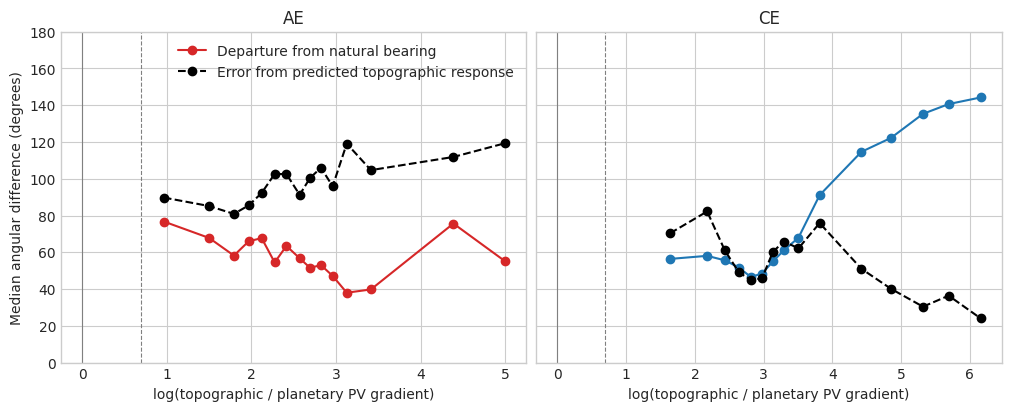

In [13]:
def circular_mean_bearing(values):
    theta = np.deg2rad(pd.Series(values).dropna())
    return np.rad2deg(np.arctan2(np.sin(theta).mean(), np.cos(theta).mean())) % 360

planetary = d[d.planetary_strong & d.direction_valid & (d.h >= 3000)].copy()
# Give each eddy equal weight: calculate an eddy bearing first, then the polarity mean.
eddy_bearings = (planetary.groupby(['Cyc', 'Eddy']).TiltDir
                 .apply(circular_mean_bearing).rename('bearing').reset_index())
natural_bearing = eddy_bearings.groupby('Cyc').bearing.apply(circular_mean_bearing)
display(natural_bearing.rename('planetary_natural_bearing_deg').round(1))

transition['dtheta_natural'] = np.nan
for cyc, bearing in natural_bearing.items():
    mask = transition.Cyc == cyc
    transition.loc[mask, 'dtheta_natural'] = tilt.angle_diff_180(transition.loc[mask, 'TiltDir'], bearing)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)
for ax, (cyc, color) in zip(axs, [('AE', 'tab:red'), ('CE', 'tab:blue')]):
    part = transition[transition.Cyc == cyc].copy()
    part['ratio_bin'] = pd.qcut(part.topo_plan_ratio, 15, duplicates='drop')
    part['topo_preference_error'] = np.where(
        part.Cyc.eq('AE'), part.dtheta_PV_grad_topo, 180.0 - part.dtheta_PV_grad_topo)
    stats = (part.groupby('ratio_bin', observed=True)
             .agg(x=('topo_plan_ratio', 'median'),
                  natural_error=('dtheta_natural', 'median'),
                  topo_error=('topo_preference_error', 'median'),
                  eddies=('Eddy', 'nunique')).reset_index(drop=True))
    ax.plot(stats.x, stats.natural_error, '-o', color=color, label='Departure from natural bearing')
    ax.plot(stats.x, stats.topo_error, '--o', color='black', label='Error from predicted topographic response')
    ax.axvline(0, color='0.5', lw=.8)
    ax.axvline(np.log(2), color='0.5', ls='--', lw=.8)
    ax.set(title=cyc, xlabel='log(topographic / planetary PV gradient)', ylim=(0, 180))
axs[0].set_ylabel('Median angular difference (degrees)')
axs[0].legend(frameon=False)

## 10. Eddy-clustered bootstrap uncertainty

Daily observations are correlated within tracks. Fix gradient-bin edges from the original sample, resample complete eddies with replacement within each polarity, and calculate 95% intervals for polarity-predicted topographic-response probability.

x      p  eddies    low   high
Cyc                                       
AE  0   1.074  0.233      78  0.172  0.300
    1   1.634  0.266     111  0.200  0.332
    2   1.909  0.245     126  0.183  0.314
    3   2.105  0.230     128  0.175  0.290
    4   2.292  0.237     127  0.164  0.311
    5   2.476  0.234     128  0.162  0.315
    6   2.655  0.262     109  0.156  0.386
    7   2.805  0.233     117  0.152  0.321
    8   2.979  0.208     117  0.145  0.288
    9   3.207  0.159     101  0.106  0.209
    10  3.944  0.131      90  0.075  0.195
    11  4.937  0.147      54  0.061  0.256
CE  0   1.749  0.332     104  0.265  0.409
    1   2.281  0.323     139  0.262  0.391
    2   2.564  0.442     164  0.364  0.522
    3   2.788  0.497     146  0.408  0.585
    4   3.000  0.487     146  0.395  0.579
    5   3.192  0.409     148  0.325  0.502
    6   3.427  0.396     126  0.303  0.485
    7   3.757  0.318     133  0.241  0.397
    8   4.474  0.475     136  0.378  0.568
    9   5.051  0.585     178  0.505  0.654
    10  5.566  0.641     171  0.561  0.708
    11  6.083  0.757     125  0.684  0.822

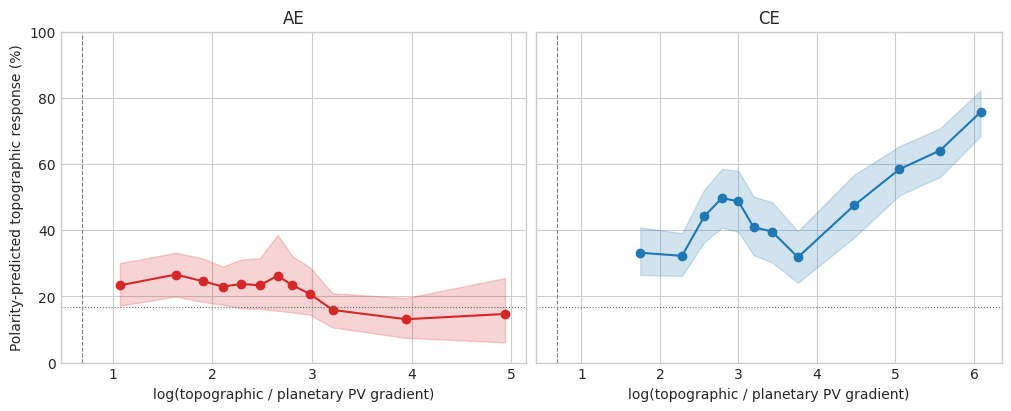

In [14]:
def clustered_alignment_bootstrap(part, angle_col='dtheta_PV_grad_topo', n_bins=12, n_boot=500, seed=42):
    part = part.dropna(subset=['topo_plan_ratio', angle_col, 'Eddy']).copy()
    edges = np.unique(part.topo_plan_ratio.quantile(np.linspace(0, 1, n_bins + 1)).to_numpy())
    part['fixed_bin'] = pd.cut(part.topo_plan_ratio, edges, include_lowest=True, duplicates='drop')
    categories = part.fixed_bin.cat.categories
    observed = (part.assign(aligned=np.where(part.Cyc.eq('AE'),part[angle_col],180.0-part[angle_col]) <= ALIGNMENT_DEG)
                .groupby('fixed_bin', observed=False).aligned.mean().reindex(categories))
    x = part.groupby('fixed_bin', observed=False).topo_plan_ratio.median().reindex(categories)
    n_eddies = part.groupby('fixed_bin', observed=False).Eddy.nunique().reindex(categories)
    groups = {eddy: frame for eddy, frame in part.groupby('Eddy')}
    ids = np.array(list(groups))
    rng = np.random.default_rng(seed)
    boot = np.full((n_boot, len(categories)), np.nan)
    for b in range(n_boot):
        sampled = rng.choice(ids, size=len(ids), replace=True)
        sample = pd.concat([groups[eddy] for eddy in sampled], ignore_index=True)
        sample['fixed_bin'] = pd.cut(sample.topo_plan_ratio, edges, include_lowest=True, duplicates='drop')
        sample['aligned'] = np.where(sample.Cyc.eq('AE'),sample[angle_col],180.0-sample[angle_col]) <= ALIGNMENT_DEG
        boot[b] = (sample.groupby('fixed_bin', observed=False).aligned.mean()
                   .reindex(categories).to_numpy())
    return pd.DataFrame({
        'x': x.to_numpy(), 'p': observed.to_numpy(), 'eddies': n_eddies.to_numpy(),
        'low': np.nanpercentile(boot, 2.5, axis=0),
        'high': np.nanpercentile(boot, 97.5, axis=0),
    })

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)
bootstrap_tables = {}
for ax, (cyc, color) in zip(axs, [('AE', 'tab:red'), ('CE', 'tab:blue')]):
    stats = clustered_alignment_bootstrap(transition[transition.Cyc == cyc], seed=42 + len(cyc))
    bootstrap_tables[cyc] = stats
    ax.plot(stats.x, 100 * stats.p, '-o', color=color)
    ax.fill_between(stats.x, 100 * stats.low, 100 * stats.high, color=color, alpha=.2)
    ax.axhline(100/6, color='0.4', ls=':', lw=.8)
    ax.axvline(np.log(2), color='0.5', ls='--', lw=.8)
    ax.set(title=cyc, xlabel='log(topographic / planetary PV gradient)', ylim=(0, 100))
axs[0].set_ylabel('Polarity-predicted topographic response (%)')
display(pd.concat(bootstrap_tables, names=['Cyc']).round(3))

## 11. Bootstrap the environmentally matched CE-AE contrast

Resample complete eddies independently within each valid environment-polarity stratum. For every replicate, recompute stratum medians and then take the median CE/AE ratio across strata.

In [15]:
matched['stratum'] = list(zip(matched.lat_bin, matched.depth_bin, matched.slope_bin))
eligible_strata = paired.index
eligible_keys = set(eligible_strata.tolist())
matched_use = matched[matched.stratum.isin(eligible_keys)].copy()
grouped_match = {(key, cyc): frame for (key, cyc), frame in matched_use.groupby(['stratum', 'Cyc'])}

rng = np.random.default_rng(123)
N_MATCH_BOOT = 2000
boot_ratios = np.full((N_MATCH_BOOT, 2), np.nan)
for b in range(N_MATCH_BOOT):
    full_ratios, fonly_ratios = [], []
    for key in eligible_keys:
        ae = grouped_match[(key, 'AE')]
        ce = grouped_match[(key, 'CE')]
        ae_sample = ae.iloc[rng.integers(0, len(ae), len(ae))]
        ce_sample = ce.iloc[rng.integers(0, len(ce), len(ce))]
        full_ratios.append(ce_sample.full_topo.median() / ae_sample.full_topo.median())
        fonly_ratios.append(ce_sample.fonly_topo.median() / ae_sample.fonly_topo.median())
    boot_ratios[b] = [np.median(full_ratios), np.median(fonly_ratios)]

matched_uncertainty = pd.DataFrame({
    'quantity': ['Full topographic term', 'f-only counterfactual'],
    'estimate': [paired.CE_AE_full_ratio.median(), paired.CE_AE_fonly_ratio.median()],
    'low_95': np.percentile(boot_ratios, 2.5, axis=0),
    'high_95': np.percentile(boot_ratios, 97.5, axis=0),
})
display(matched_uncertainty.round(3))

,quantity,estimate,low_95,high_95
0,Full topographic term,1.661,1.555,1.876
1,f-only counterfactual,1.015,0.947,1.086


## 12. Inspect observations with nonpositive absolute vorticity

Any `Ro_signed <= -1` observation reverses the topographic PV-gradient vector and may indicate a dynamically extreme AE or a noisy vorticity estimate. Inspect the complete track and compare the value with neighbouring days before retaining it.

,Eddy,Day,Cyc,lat,f,w,Ro_signed,absolute_vorticity_factor,TiltDis,dtheta_PV_grad
49291,1137,4988,AE,-36.750739,-0.000087,0.000018,-0.208348,0.791652,NaN,NaN
49292,1137,4989,AE,-36.795650,-0.000087,0.000023,-0.260206,0.739794,NaN,NaN
49293,1137,4990,AE,-36.840562,-0.000087,0.000027,-0.307085,0.692915,NaN,NaN
49294,1137,4991,AE,-36.885476,-0.000087,0.000031,-0.348689,0.651311,18.676359,125.889341
49295,1137,4992,AE,-36.939560,-0.000088,0.000065,-0.737923,0.262077,16.423011,174.006832
49296,1137,4993,AE,-36.592166,-0.000087,0.000021,-0.242078,0.757922,12.786768,173.813940
49297,1137,4994,AE,-36.765867,-0.000087,0.000075,-0.854911,0.145089,11.132021,136.845045
49298,1137,4995,AE,-36.720502,-0.000087,0.000071,-0.812150,0.187850,15.193918,98.663441
49299,1137,4996,AE,-36.763470,-0.000087,0.000075,-0.857980,0.142020,15.106000,88.513789
49300,1137,4997,AE,-36.778554,-0.000087,0.000081,-0.929891,0.070109,6.682135,75.822826


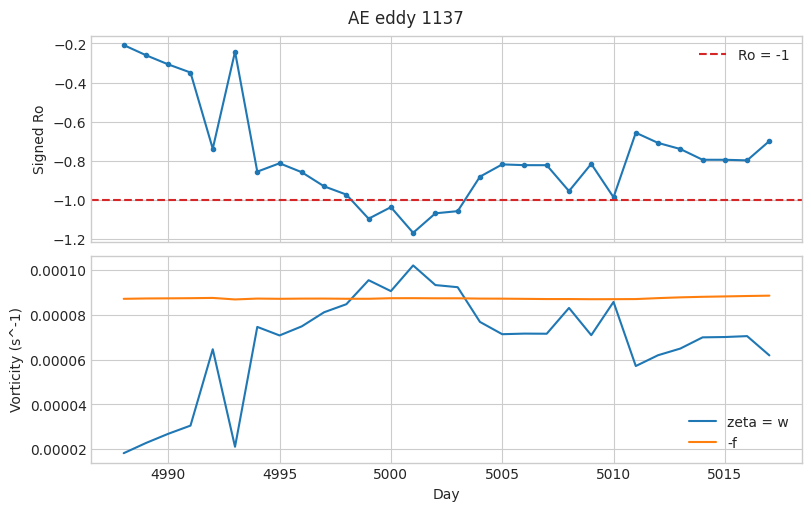

In [16]:
extreme_ids = valid.loc[valid.absolute_vorticity_factor <= 0, 'Eddy'].unique()
for eddy_id in extreme_ids:
    track = d[d.Eddy == eddy_id].sort_values('Day').copy()
    display(track[['Eddy', 'Day', 'Cyc', 'lat', 'f', 'w', 'Ro_signed',
                   'absolute_vorticity_factor', 'TiltDis', 'dtheta_PV_grad']])
    fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex=True, constrained_layout=True)
    axs[0].plot(track.Day, track.Ro_signed, '-o', ms=3)
    axs[0].axhline(-1, color='tab:red', ls='--', label='Ro = -1')
    axs[0].set_ylabel('Signed Ro')
    axs[0].legend(frameon=False)
    axs[1].plot(track.Day, track.w, label='zeta = w')
    axs[1].plot(track.Day, -track.f, label='-f')
    axs[1].set(xlabel='Day', ylabel='Vorticity (s^-1)')
    axs[1].legend(frameon=False)
    fig.suptitle(f'{track.Cyc.iloc[0]} eddy {eddy_id}')

## 13. Interpretation safeguards and next model

1. `Ro_signed` and the full topographic PV gradient are mathematically coupled, so do not interpret their raw correlation as independent evidence. The counterfactual and factorized analyses are more informative.
2. Daily observations within an eddy are correlated. Add eddy-clustered bootstrap intervals or a mixed-effects model before making inferential claims.
3. Do not choose a PV or Ro threshold by maximising alignment in the same observations used for evaluation. Compare smooth and segmented models using held-out eddies.
4. The approximation `grad(zeta) approximately 0` creates an effective core-mean PV-gradient diagnostic. If gridded velocity fields are available, compare `grad(zeta)/h` with the retained planetary and topographic terms.
5. A formal model should predict continuous angular mismatch or aligned/not-aligned status from `log(B0)`, signed `Ro`, polarity and their interactions, with eddy and region grouping.